## Sentence-BERT Classification

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv("ds_task_dataset.csv")
print(f"Shape: {df.shape} | Classes: {df['label'].nunique()}")
print(df["label"].value_counts().sort_index())

sbert = SentenceTransformer("all-mpnet-base-v2")
X = sbert.encode(
    df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
y = df["label"].values
print(f"\nEmbeddings: {X.shape}")

# Stratified 85 / 15 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Shape: (2169, 2) | Classes: 10
label
0    227
1    222
2    221
3    220
4    217
5    215
6    213
7    212
8    211
9    211
Name: count, dtype: int64


Batches:   0%|          | 0/34 [00:00<?, ?it/s]


Embeddings: (2169, 768)
Train: 1843 | Test: 326


### 5-Fold Stratified Cross-Validation (sklearn models, train set)

In [ ]:
from sklearn.model_selection import GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid={"C": [0.01, 0.1, 1, 10, 100]},
    cv=cv,
    scoring="f1_macro",
    refit=True,
    n_jobs=-1,
)
lr_grid.fit(X_train, y_train)

svm_grid = GridSearchCV(
    CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_STATE)),
    param_grid={"estimator__C": [0.01, 0.1, 1, 10, 100]},
    cv=cv,
    scoring="f1_macro",
    refit=True,
    n_jobs=-1,
)
svm_grid.fit(X_train, y_train)

mlp_grid = GridSearchCV(
    MLPClassifier(
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
    ),
    param_grid={
        "hidden_layer_sizes": [
            (256,),
            (512,),
            (256, 128),
            (512, 256),
            (512, 256, 128),
        ]
    },
    cv=cv,
    scoring="f1_macro",
    refit=True,
    n_jobs=1,   # MLP is not thread-safe with multiple workers
)
mlp_grid.fit(X_train, y_train)

grids = {
    "Logistic Regression": (lr_grid, "C"),
    "Linear SVM":          (svm_grid, "estimator__C"),
    "MLP (sklearn)":       (mlp_grid, "hidden_layer_sizes"),
}

rows = []
for name, (gs, param_key) in grids.items():
    r = gs.cv_results_
    rows.append({
        "Model":        name,
        "Best param":   gs.best_params_[param_key],
        "CV F1 Macro":  f"{gs.best_score_:.4f}",
        "CV F1 std":    f"{r['std_test_score'][gs.best_index_]:.4f}",
    })

pd.DataFrame(rows).set_index("Model")

,Best param,CV F1 Macro,CV F1 std
Model,,,
Logistic Regression,100,0.9608,0.0081
Linear SVM,10,0.9623,0.0065
MLP (sklearn),"(256, 128)",0.9498,0.0056


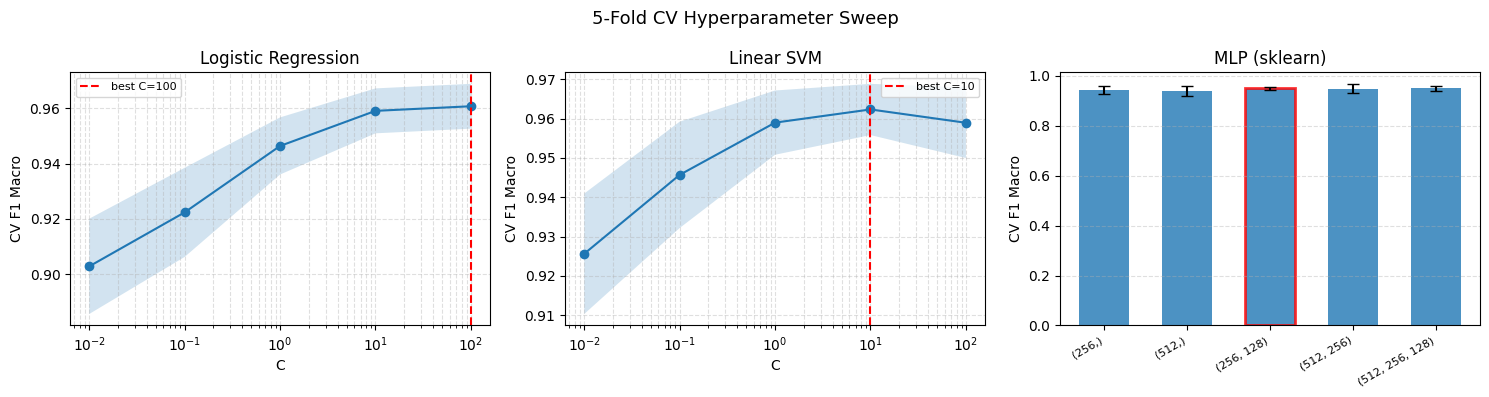

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# LR and SVM share the same C values to line plots
for ax, (name, (gs, param_key)) in zip(axes[:2], list(grids.items())[:2]):
    r = gs.cv_results_
    cs     = [p[param_key] for p in r["params"]]
    means  = r["mean_test_score"]
    stds   = r["std_test_score"]
    best_c = gs.best_params_[param_key]
    ax.semilogx(cs, means, marker="o")
    ax.fill_between(cs, means - stds, means + stds, alpha=0.2)
    ax.axvline(best_c, color="red", linestyle="--", label=f"best C={best_c}")
    ax.set_xlabel("C")
    ax.set_ylabel("CV F1 Macro")
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", ls="--", alpha=0.4)

# MLP to bar chart
ax = axes[2]
r   = mlp_grid.cv_results_
labels = [str(p["hidden_layer_sizes"]) for p in r["params"]]
means  = r["mean_test_score"]
stds   = r["std_test_score"]
x = np.arange(len(labels))
bars = ax.bar(x, means, yerr=stds, capsize=4, width=0.6, alpha=0.8)
bars[mlp_grid.best_index_].set_edgecolor("red")
bars[mlp_grid.best_index_].set_linewidth(2)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("CV F1 Macro")
ax.set_title("MLP (sklearn)")
ax.grid(axis="y", ls="--", alpha=0.4)

plt.suptitle("5-Fold CV Hyperparameter Sweep", fontsize=13)
plt.tight_layout()
plt.show()

### Model Training

In [5]:
def compute_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy":        accuracy_score(y_true, y_pred),
        "Precision Macro": precision_score(y_true, y_pred, average="macro"),
        "Recall Macro":    recall_score(y_true, y_pred, average="macro"),
        "F1 Macro":        f1_score(y_true, y_pred, average="macro"),
        "ROC-AUC (OvR)":   roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }


# Use the best estimators (already refit on full X_train by GridSearchCV)
sklearn_models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Linear SVM":          svm_grid.best_estimator_,
    "MLP (sklearn)":       mlp_grid.best_estimator_,
}

### Final Evaluation on Test Set

In [6]:
test_results = {}
all_test_preds = {}

for name, clf in sklearn_models.items():
    preds = clf.predict(X_test)
    all_test_preds[name] = preds
    test_results[name] = compute_metrics(y_test, preds, clf.predict_proba(X_test))

test_df = pd.DataFrame(test_results).T.round(4)
print("Test Set:")
test_df.sort_values("F1 Macro", ascending=False)

Test Set:


,Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC-AUC (OvR)
Logistic Regression,0.9571,0.9582,0.9570,0.9572,0.9991
Linear SVM,0.9540,0.9556,0.9540,0.9542,0.9989
MLP (sklearn),0.9540,0.9555,0.9538,0.9540,0.9992


In [7]:
best_name = test_df["F1 Macro"].idxmax()
print(f"Best model: {best_name}\n")
print(classification_report(y_test, all_test_preds[best_name]))

Best model: Logistic Regression

              precision    recall  f1-score   support

           0       0.89      0.91      0.90        34
           1       0.97      1.00      0.99        33
           2       1.00      0.97      0.98        33
           3       1.00      0.97      0.98        33
           4       0.94      1.00      0.97        33
           5       1.00      0.94      0.97        32
           6       1.00      1.00      1.00        32
           7       0.94      0.91      0.92        32
           8       0.91      0.97      0.94        32
           9       0.94      0.91      0.92        32

    accuracy                           0.96       326
   macro avg       0.96      0.96      0.96       326
weighted avg       0.96      0.96      0.96       326



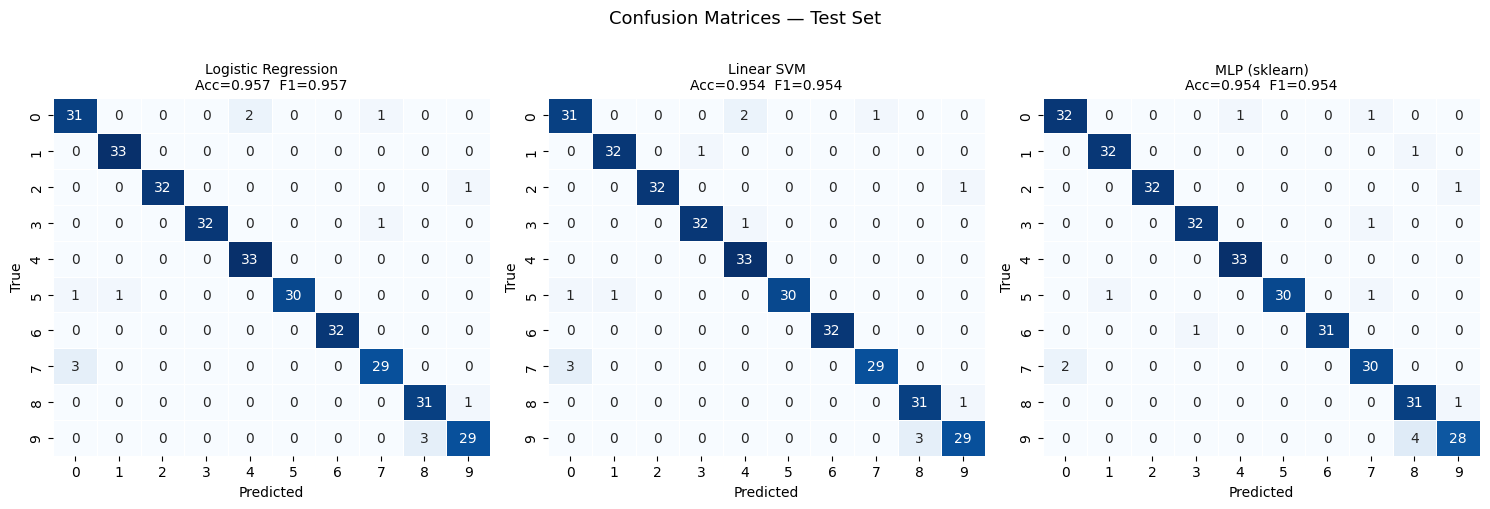

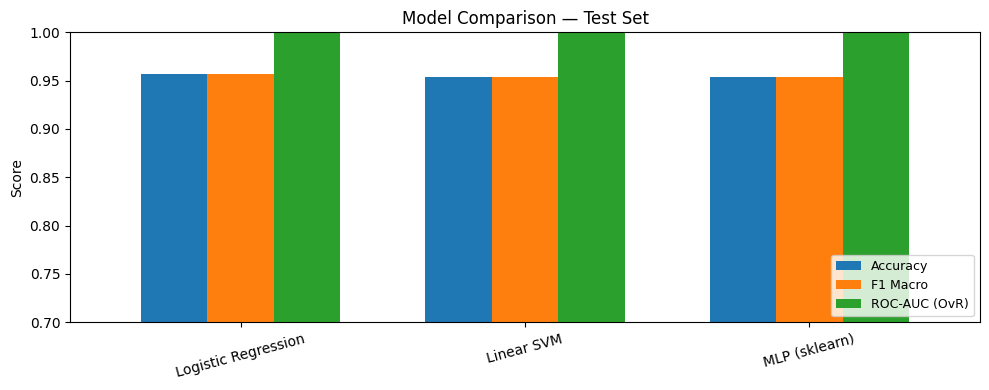

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, preds) in zip(axes, all_test_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False, linewidths=0.4)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="macro")
    ax.set_title(f"{name}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle("Confusion Matrices - Test Set", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

metrics_to_plot = ["Accuracy", "F1 Macro", "ROC-AUC (OvR)"]
test_df[metrics_to_plot].plot(kind="bar", figsize=(10, 4), rot=15, width=0.7)
plt.title("Model Comparison - Test Set")
plt.ylabel("Score")
plt.ylim(0.7, 1.0)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### Failure Cases — Best Model (Logistic Regression)

In [9]:
# Reconstruct test indices using the same split parameters
idx = np.arange(len(df))
_, test_idx = train_test_split(idx, test_size=0.15, stratify=y, random_state=RANDOM_STATE)

df_test = df.iloc[test_idx].reset_index(drop=True).copy()
df_test["y_pred"] = all_test_preds[best_name]
df_test["correct"] = df_test["label"] == df_test["y_pred"]

failures = df_test[~df_test["correct"]].copy()
print(f"Total misclassified: {len(failures)} / {len(df_test)}")
print(f"\nFailures per true class:")
print(failures["label"].value_counts().sort_index())


Total misclassified: 14 / 326

Failures per true class:
label
0    3
2    1
3    1
5    2
7    3
8    1
9    3
Name: count, dtype: int64


In [12]:
pd.set_option("display.max_colwidth", None)

for true_label in sorted(failures["label"].unique()):
    group = failures[failures["label"] == true_label][["text", "label", "y_pred"]]
    group = group.rename(columns={"label": "true_label", "y_pred": "pred_label"})
    print(f"\n{'='*80}")
    print(f"  True class {true_label} ->  misclassified as: {sorted(group['pred_label'].tolist())}")
    print(f"{'='*80}")
    for _, row in group.iterrows():
        print(f"\n  [true={row['true_label']}  pred={row['pred_label']}]")
        print(f"  {row['text']}")



  True class 0 ->  misclassified as: [4, 4, 7]

  [true=0  pred=4]
  I received a fee I should not have.

  [true=0  pred=4]
  I was spending cash with my card and got a fee.

  [true=0  pred=7]
  My card was charged more than expected.

  True class 2 ->  misclassified as: [9]

  [true=2  pred=9]
  The balance on my account wasn't updated after I made a depost.

  True class 3 ->  misclassified as: [7]

  [true=3  pred=7]
  i did not get any money but still was charged

  True class 5 ->  misclassified as: [0, 1]

  [true=5  pred=1]
  I need a transaction reversed from my account.

  [true=5  pred=0]
  I have been overcharged.

  True class 7 ->  misclassified as: [0, 0, 0]

  [true=7  pred=0]
  I was charge a fee that I wasn't told about

  [true=7  pred=0]
  I don't appreciate the extra fees being siphoned from my account. I was helping some friends move to Japan and we were buying home decorations at the local stores. The  receipts differed greatly from what showed up in my bank a